# 1. Histograma y Diag. de barras - STATSBOMB

In [2]:
pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 5.6 MB/s eta 0:00:00


### Importar librerías

In [3]:
import pandas as pd
import numpy as np
from mplsoccer import Sbopen, FontManager
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
from PIL import Image
from io import BytesIO

### Importar datos

In [4]:
game_id = 3943043

In [5]:
parser = Sbopen()

In [6]:
df_events = parser.event(game_id)[0][['team_name', 'player_name','minute','type_name']]

In [7]:
df_passes = df_events[df_events['type_name']=='Pass'].reset_index(drop=True)

In [8]:
df_passes.head(3)

,team_name,player_name,minute,type_name
0,England,Kobbie Mainoo,0,Pass
1,England,Jordan Pickford,0,Pass
2,Spain,Unai Simón Mendibil,0,Pass


In [9]:
team = 'Spain'
df_passes_team = df_passes[df_passes['team_name'] == team].copy()

#### Font and image

In [10]:
font = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true')
#image_url = 'URL IMAGEN'

#### Chart display: Team passes

In [11]:
def add_image_from_url(url, x_pos, y_pos, size, relative_to):
    """
    Añade una imagen a un gráfico desde una URL.

    Parámetros:
    - url: Link de la imagen.
    - x_pos, y_pos: Posición en el gráfico.
    - size: Tamaño (zoom) de la imagen (ej: 0.1).
    - relative_to:
        * 'data': Usa los números de los ejes (ej: Goles).
        * 'axes': Usa el área del gráfico (0 a 1).
        * 'figure': Usa toda la imagen final (0 a 1).
    """
    # Descarga y procesa la imagen
    response = requests.get(url, timeout=5)
    img = Image.open(BytesIO(response.content)).convert('RGBA')

    # Define el sistema de coordenadas
    coord_style = relative_to if relative_to == 'data' else f'{relative_to} fraction'

    # Crea y añade la imagen al gráfico
    imagebox = OffsetImage(img, zoom=size)
    ax.add_artist(AnnotationBbox(imagebox, (x_pos, y_pos), xycoords=coord_style, frameon=False))

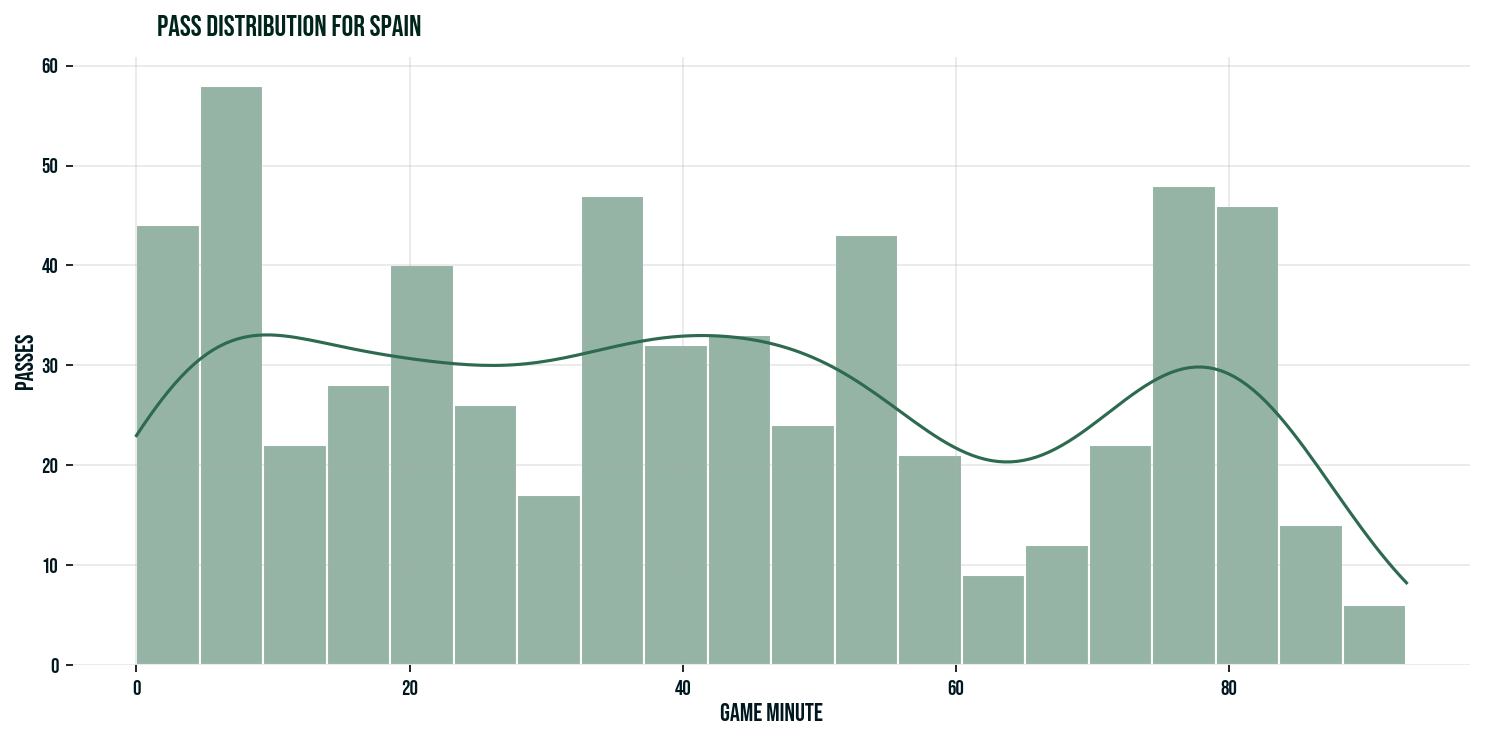

In [12]:
fig, ax = plt.subplots(figsize=(10,5), dpi=150)

# Histogram
sns.histplot(df_passes_team['minute'], bins=20, kde=True, color='#2d6a4f', edgecolor='white', ax=ax)

# Title and logo
#add_image_from_url(image_url, x_pos=0.03, y_pos=1.06, size=0.075, relative_to='axes')
title = f'Pass distribution for {team}'
ax.text(s=title,fontproperties=font.prop,fontsize=14,color='#00241b',fontweight='bold',x=0.06, y=1.034,ha='left',va='bottom',transform=ax.transAxes)



# Añadir etiquetas encima de cada barra
#for patch in ax.patches:
#    height = patch.get_height()
#    ax.text(patch.get_x() + patch.get_width() / 2,height + 1,str(int(height)),ha='center',fontsize=9,color='#00171f',fontproperties=font.prop)


# Características de los ejes
ax.set_xlabel('Game minute', fontproperties=font.prop, fontsize=12, color='#00171f')
ax.set_ylabel('Passes', fontproperties=font.prop, fontsize=12, color='#00171f')

for label in ax.get_xticklabels():
    label.set_fontproperties(font.prop)
    label.set_fontsize(10)
    label.set_color('#00171f')

for label in ax.get_yticklabels():
    label.set_fontproperties(font.prop)
    label.set_fontsize(10)
    label.set_color('#00171f')

ax.spines['top'].set_visible(False)    # Quitar línea superior
ax.spines['right'].set_visible(False)  # Quitar línea derecha
ax.spines['left'].set_visible(False)   # Quitar línea izquierda (eje Y)
ax.spines['bottom'].set_visible(False) # Quitar línea inferior (eje X)

# lo mimsmo de arriba pero en un bucle

#for side in ['top', 'right', 'left', 'bottom']:
#    ax.spines[side].set_visible(False)

ax.grid(alpha=0.3) # transparencia de las rayas del grid

plt.tight_layout() # que quede todo bien distribuido

#### Pases de jugadores

In [13]:
# Agrupar los datos por player_name y contar los pases por jugador
df_passes_count = df_passes.groupby('player_name').size().reset_index(name='num_passes')

# Ordenar las barras por recuento de pases de forma descendente
df_passes_count = df_passes_count.sort_values(by='num_passes', ascending=False)

In [15]:
df_passes_count.head()

,player_name,num_passes
23,Robin Aime Robert Le Normand,84
0,Aymeric Laporte,83
3,Daniel Carvajal Ramos,73
6,Fabián Ruiz Peña,63
20,Nicholas Williams Arthuer,51


In [16]:
title = 'Pases por jugador'

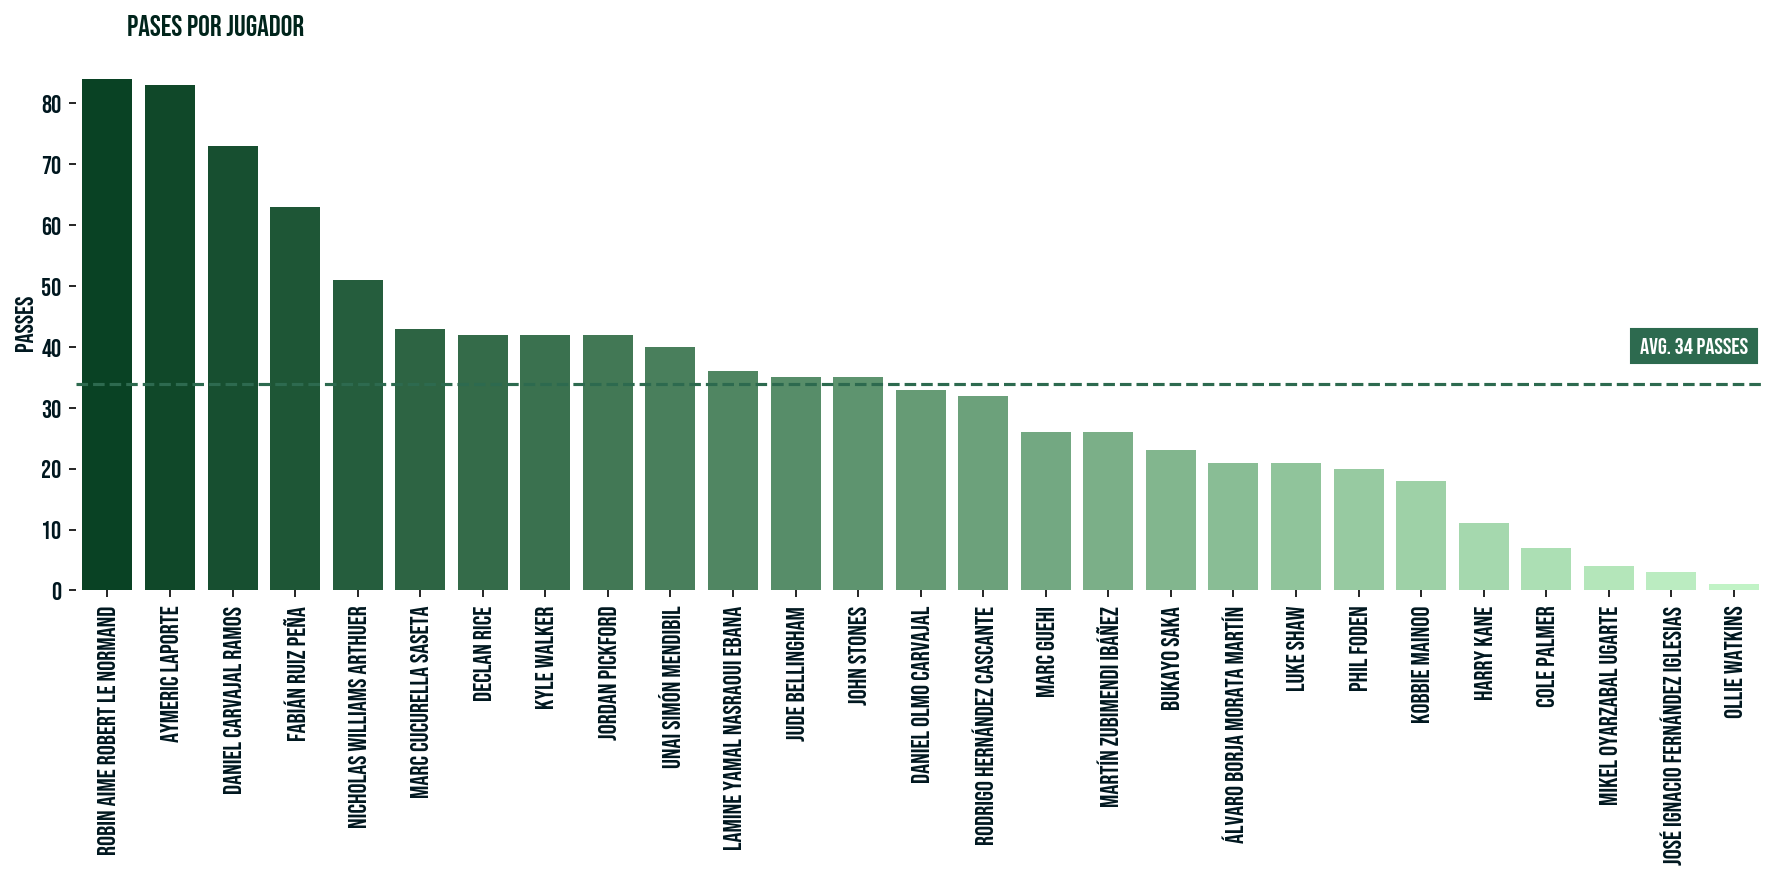

In [17]:
# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# Title and logo
#add_image_from_url(image_url, x_pos=0.01, y_pos=1.06, size=0.075, relative_to='axes')
ax.text(s=title,fontproperties=font.prop,fontsize=14,color='#00241b',fontweight='bold',x=0.03, y=1.034,ha='left',va='bottom',transform=ax.transAxes)

# Crear un mapa personalizado entre dos verdes
green_cmap = LinearSegmentedColormap.from_list('custom_green', ['#004b23', '#b9fbc0'])
palette = [green_cmap(i) for i in np.linspace(0, 1, len(df_passes_count))]

# Gráfico barras, x nombre e y numpases
sns.barplot(x='player_name', y='num_passes', data=df_passes_count, hue='player_name', palette=palette, legend=False, width=0.8)

ax.axhline(df_passes_count['num_passes'].mean(), linestyle='--', color='#2d6a4f')
ax.text(
    x=df_passes['player_name'].nunique()-2.5,  # Coloca el texto un poco a la izquierda del final del gráfico
    y=df_passes_count['num_passes'].mean() + 5,  # Coloca el texto un poco encima de la línea de la media
    s='Avg. {:.0f} passes'.format(df_passes_count['num_passes'].mean()),
    backgroundcolor='#2d6a4f',
    fontsize=11,
    fontweight='bold',
    rotation=0,
    color='white',
    fontproperties=font.prop
)

ax.set_xlabel('')  # Elimina la etiqueta del eje X
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontproperties=font.prop, fontsize=12, color='#00171f')  # Rota los nombres del eje X
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=font.prop, fontsize=12, color='#00171f')
ax.set_ylabel('PASSES', fontproperties=font.prop, fontsize=12, color='#00171f')

ax.spines['top'].set_visible(False)    # Quitar línea superior
ax.spines['right'].set_visible(False)  # Quitar línea derecha
ax.spines['left'].set_visible(False)   # Quitar línea izquierda (eje Y)
ax.spines['bottom'].set_visible(False) # Quitar línea inferior (eje X)

# Ajustar la visualización
plt.tight_layout()

#### Pases por jugador - Forma horizontal

In [18]:
# Agrupar los datos por player_name y contar los pases por jugador
df_passes_count = df_passes.groupby('player_name').size().reset_index(name='num_passes')

# Ordenar las barras por recuento de pases de forma descendente
df_passes_count = df_passes_count.sort_values(by='num_passes', ascending=False)

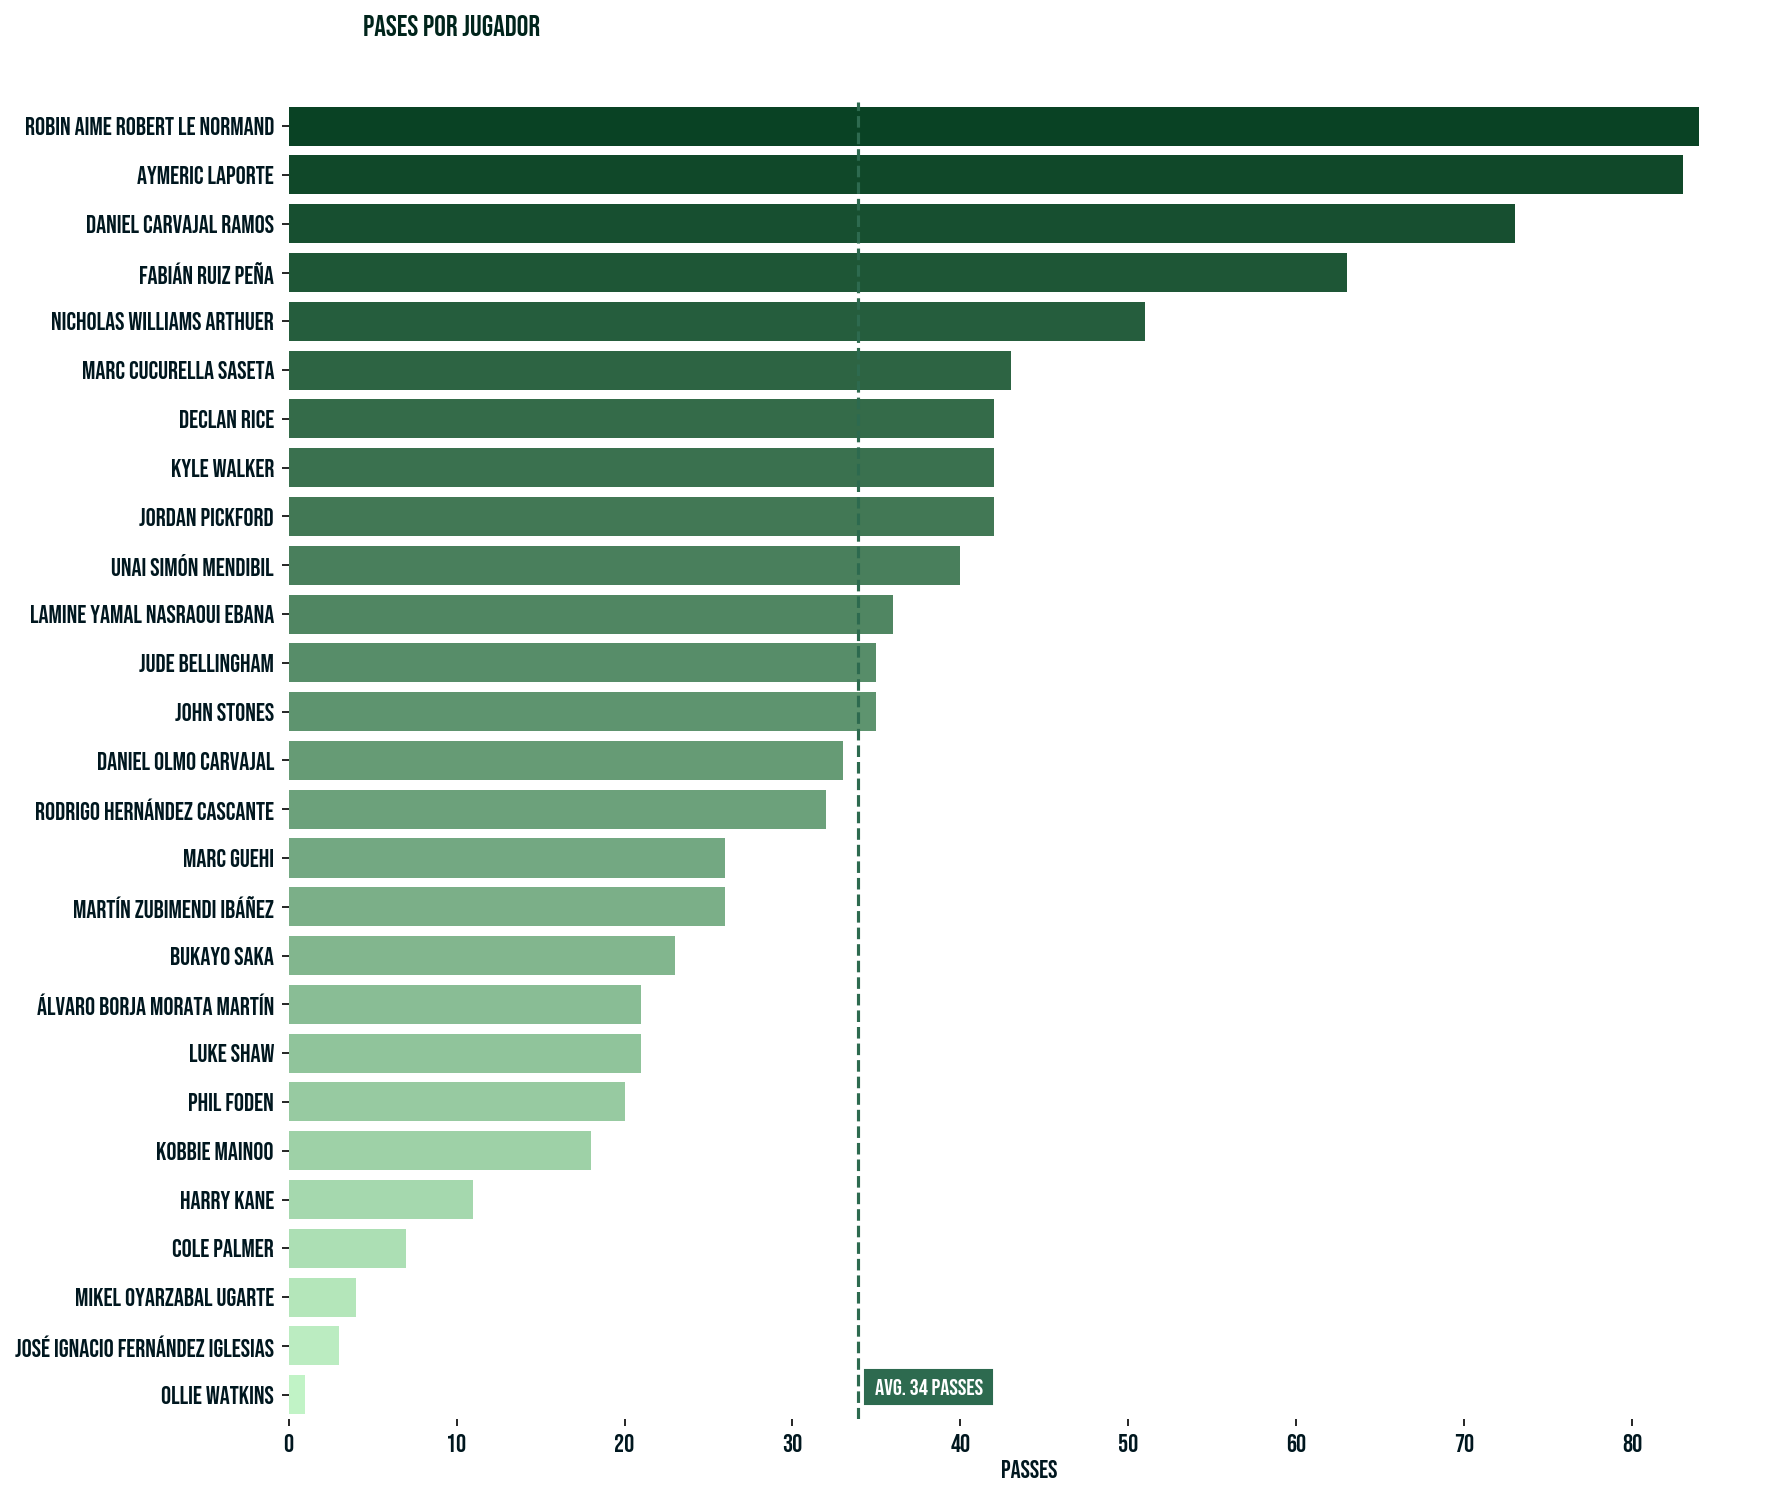

In [19]:
# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

# Title and logo
#add_image_from_url(image_url, x_pos=0.03, y_pos=1.06, size=0.075, relative_to='axes')
ax.text(s=title,fontproperties=font.prop,fontsize=14,color='#00241b',fontweight='bold',x=0.05, y=1.05,ha='left',va='bottom',transform=ax.transAxes)

# Crear un mapa personalizado entre dos verdes
green_cmap = LinearSegmentedColormap.from_list('custom_green', ['#004b23', '#b9fbc0'])
palette = [green_cmap(i) for i in np.linspace(0, 1, len(df_passes_count))]

# Gráfico de barras x numpases e y jugador
sns.barplot(x='num_passes',y='player_name',data=df_passes_count,hue='player_name',palette=palette,legend=False,width=0.8)

ax.axvline(df_passes_count['num_passes'].mean(), linestyle='--', color='#2d6a4f')
ax.text(
    x=df_passes_count['num_passes'].mean() + 1,
    y=df_passes_count['player_name'].nunique()-1,
    s='Avg. {:.0f} passes'.format(df_passes_count['num_passes'].mean()),
    backgroundcolor='#2d6a4f',
    fontsize=11,
    fontweight='bold',
    rotation=0,
    color='white',
    fontproperties=font.prop
)

ax.set_ylabel('')  # Elimina la etiqueta del eje X
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=font.prop, fontsize=12, color='#00171f')  # Rota los nombres del eje X
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font.prop, fontsize=12, color='#00171f')  # Rota los nombres del eje X
ax.set_xlabel('PASSES', fontproperties=font.prop, fontsize=12, color='#00171f')

ax.spines['top'].set_visible(False)    # Quitar línea superior
ax.spines['right'].set_visible(False)  # Quitar línea derecha
ax.spines['left'].set_visible(False)   # Quitar línea izquierda (eje Y)
ax.spines['bottom'].set_visible(False) # Quitar línea inferior (eje X)

# Ajustar la visualización
plt.tight_layout()

# 2. Graf. de area y de línea - UNDERSTAT

In [22]:
pip install understatapi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 13.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.1/138.1 kB 6.0 MB/s eta 0:00:00
  Created wheel for understatapi: filename=understatapi-0.7.1-py3-none-any.whl size=15443 sha256=46469661145c5c84907a6557b7a8e16b3e9d42355c3693e7343dd158418db25d
  Stored in directory: /root/.cache/pip/wheels/38/de/d6/f84cd8cb7746c9685b36beb27b8840f43e8b3f93cf288343c5
Successfully built understatapi
  Attem

In [23]:
from understatapi import UnderstatClient
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import FontManager
from PIL import Image
from io import BytesIO
import math

In [24]:
team = 'Arsenal'
season = '2025'

In [25]:
understat = UnderstatClient()
team_match_data = understat.team(team=team).get_match_data(season=season)
df_matches = pd.DataFrame(team_match_data)

In [26]:
df_matches.head(2)

,id,isResult,side,h,a,goals,xG,datetime,forecast,result
0,28786,True,a,"{'id': '89', 'title': 'Manchester United', 'sh...","{'id': '83', 'title': 'Arsenal', 'short_title'...","{'h': '0', 'a': '1'}","{'h': '1.37653', 'a': '1.3304'}",2025-08-17 15:30:00,"{'w': 0.3817588149943814, 'd': 0.2577168882865...",w
1,28793,True,h,"{'id': '83', 'title': 'Arsenal', 'short_title'...","{'id': '245', 'title': 'Leeds', 'short_title':...","{'h': '5', 'a': '0'}","{'h': '2.73761', 'a': '0.156761'}",2025-08-23 16:30:00,"{'w': 0.9067498955784903, 'd': 0.0817528618969...",w


In [27]:
columns = ['h','a','xG']
for col in columns:
    df_matches = df_matches.join(df_matches[col].apply(pd.Series).add_prefix(f'{col}_'))

In [28]:
df_matches.head(1)

,id,isResult,side,h,a,goals,xG,datetime,forecast,result,h_id,h_title,h_short_title,a_id,a_title,a_short_title,xG_h,xG_a
0,28786,True,a,"{'id': '89', 'title': 'Manchester United', 'sh...","{'id': '83', 'title': 'Arsenal', 'short_title'...","{'h': '0', 'a': '1'}","{'h': '1.37653', 'a': '1.3304'}",2025-08-17 15:30:00,"{'w': 0.3817588149943814, 'd': 0.2577168882865...",w,89,Manchester United,MUN,83,Arsenal,ARS,1.37653,1.3304


In [29]:
pd.concat([df_matches['h_title'], df_matches['a_title']]).unique()

array(['Manchester United', 'Arsenal', 'Liverpool', 'Newcastle United',
       'Fulham', 'Burnley', 'Sunderland', 'Chelsea', 'Aston Villa',
       'Everton', 'Bournemouth', 'Nottingham Forest', 'Leeds',
       'Brentford', 'Wolverhampton Wanderers', 'Tottenham', 'Brighton',
       'Manchester City', 'West Ham', 'Crystal Palace'], dtype=object)

In [30]:
df = df_matches.copy()
df_team = df[(df['h_title'] == team) | (df['a_title'] == team)].copy().reset_index(drop=True)

# Asignar rival para identificarlo en el gráfico
df_team['rival'] = np.where(df_team['h_title'] == team, df_team['a_title'], df_team['h_title'])

In [31]:
# Asignar xG del equipo y del rival
df_team['xG_Team'] = np.where(df_team['h_title'] == team, df_team['xG_h'],df_team['xG_a'])
df_team['xG_Rival'] = np.where(df_team['h_title'] == team, df_team['xG_a'], df_team['xG_h'])
df_team[['xG_Team', 'xG_Rival']] = df_team[['xG_Team', 'xG_Rival']].astype(float)

In [32]:
# Crea columna combinada de fecha y rival para el eje x
df_team['datetime'] = pd.to_datetime(df_team['datetime'])
df_team['datetime_rival'] = df_team['datetime'].dt.strftime('%d-%m') + ' vs ' + df_team['rival']

df_team = df_team.sort_values('datetime', ascending=True)
df_team = df_team[['datetime','datetime_rival','rival','xG_Team','xG_Rival']]

In [35]:
df_team_mapping = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Providers_Team_Mapping.xlsx')

df_team = df_team.merge(df_team_mapping[['Understat', 'Team_Color']],how='left',left_on='rival',right_on='Understat')
df_team.drop(columns='Understat', inplace=True)

In [36]:
font_title = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true')
font_text = FontManager('https://github.com/google/fonts/blob/main/ofl/barlowcondensed/BarlowCondensed-Medium.ttf?raw=true')

In [37]:
def add_image_from_url(url, x_pos, y_pos, size, relative_to):
    """
    Añade una imagen a un gráfico desde una URL.

    Parámetros:
    - url: Link de la imagen.
    - x_pos, y_pos: Posición en el gráfico.
    - size: Tamaño (zoom) de la imagen (ej: 0.1).
    - relative_to:
        * 'data': Usa los números de los ejes (ej: Goles).
        * 'axes': Usa el área del gráfico (0 a 1).
        * 'figure': Usa toda la imagen final (0 a 1).
    """
    # Descarga y procesa la imagen
    response = requests.get(url, timeout=5)
    img = Image.open(BytesIO(response.content)).convert('RGBA')

    # Define el sistema de coordenadas
    coord_style = relative_to if relative_to == 'data' else f'{relative_to} fraction'

    # Crea y añade la imagen al gráfico
    imagebox = OffsetImage(img, zoom=size)
    ax.add_artist(AnnotationBbox(imagebox, (x_pos, y_pos), xycoords=coord_style, frameon=False))

In [38]:
season_start_year = df_team['datetime'].dt.year.min()
season_end_year = season_start_year + 1
title = f'xG vs xG rival temporada {season_start_year}-{season_end_year} - '

In [39]:
team_logo = df_team_mapping.loc[df_team_mapping['Understat'] == team, 'Team_Logo'].values[0]
team_color = df_team_mapping.loc[df_team_mapping['Understat'] == team, 'Team_Color'].values[0]
opponent_color = '#2d3f52'
bg_color = '#f8f9fa'

In [40]:
df_team.head(2)

,datetime,datetime_rival,rival,xG_Team,xG_Rival,Team_Color
0,2025-08-17 15:30:00,17-08 vs Manchester United,Manchester United,1.33040,1.376530,#DA291C
1,2025-08-23 16:30:00,23-08 vs Leeds,Leeds,2.73761,0.156761,NaN


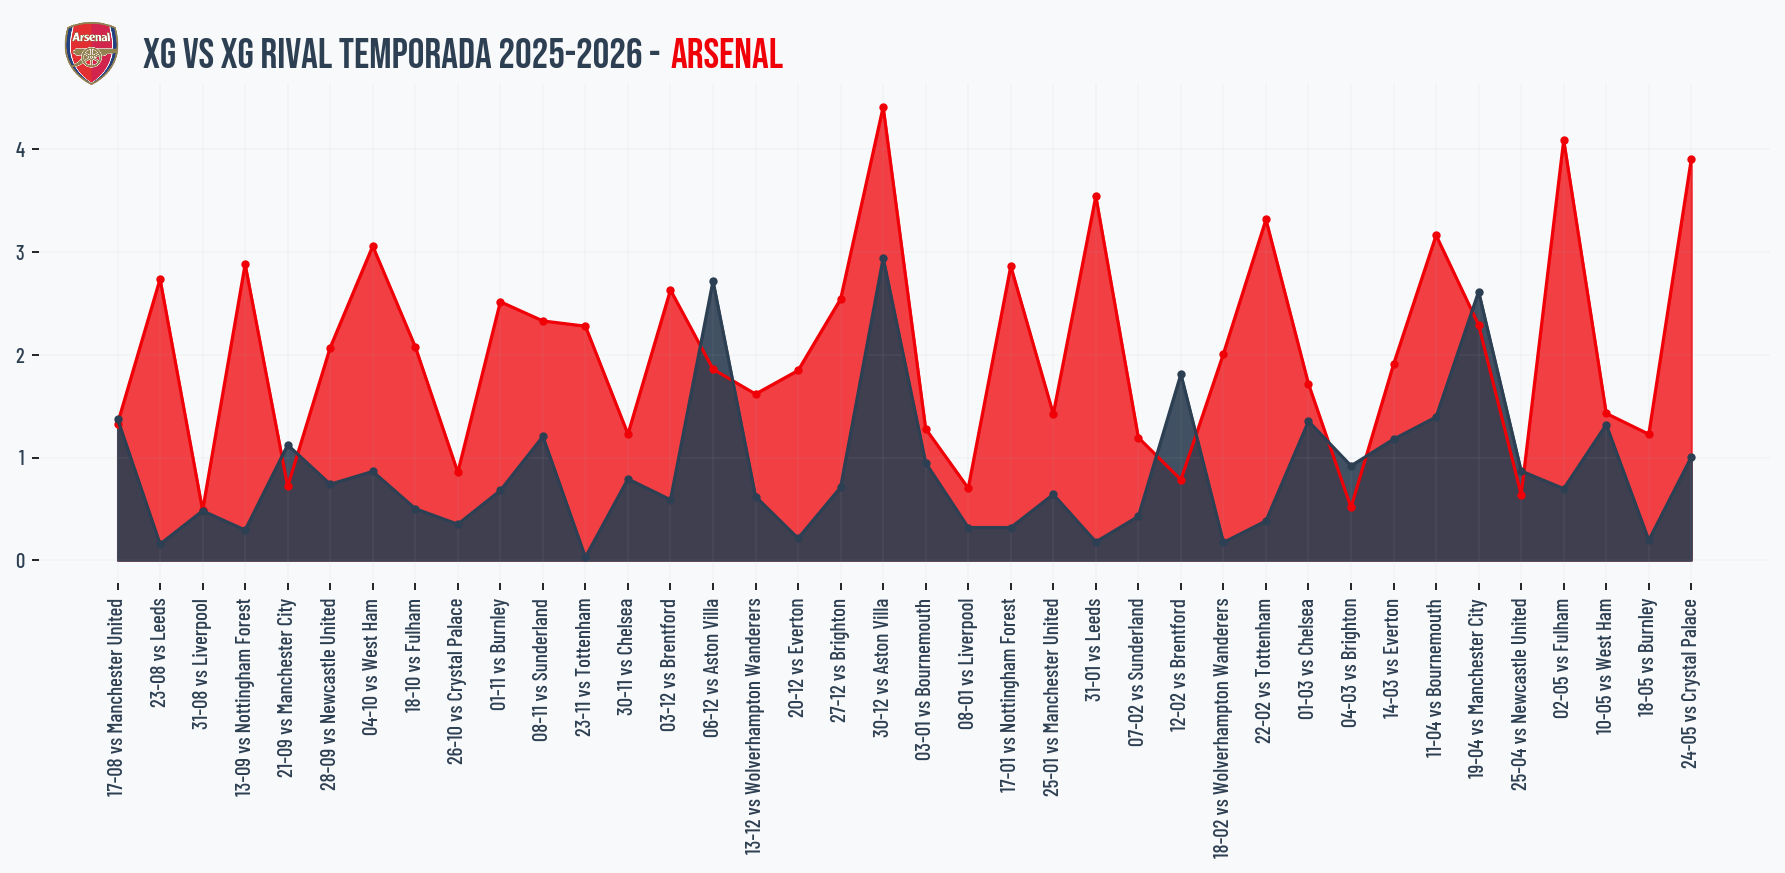

In [41]:
fig, ax = plt.subplots(figsize=(12,6), dpi=150)

# Title and logo
add_image_from_url(team_logo, x_pos=0.03, y_pos=1.06, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.034, fontsize=20, fontweight='bold', ha='left', va='bottom', s=title, fontproperties=font_title.prop, color=opponent_color, transform=ax.transAxes)
ax.text(x=0.365, y=1.034, fontsize=20, fontweight='bold', ha='left', va='bottom', s=team, fontproperties=font_title.prop, color=team_color, transform=ax.transAxes)

# Lines
ax.plot(df_team['datetime_rival'], df_team['xG_Team'], label='xG del equipo', color=team_color, marker='o', markersize=3)
ax.plot(df_team['datetime_rival'], df_team['xG_Rival'], label='xG del rival', color=opponent_color, marker='o', markersize=3)

# Areas
ax.fill_between(df_team['datetime_rival'], df_team['xG_Team'], color=team_color, alpha=0.75)
ax.fill_between(df_team['datetime_rival'], df_team['xG_Rival'], color=opponent_color, alpha=0.9)

# Other customizations
ax.set_xlabel('')  # Elimina la etiqueta del eje X
ax.set_ylabel('') # Elimina la etiqueta del eje X
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontproperties=font_text.prop, fontsize=10, color=opponent_color)  # Rota los nombres del eje X
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=font_text.prop, fontsize=10, color=opponent_color)  # Custom los nombres del eje X

for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_visible(False)

ax.grid(alpha=0.075)

fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

plt.tight_layout()

### Multiple subplots

In [42]:
def get_team_matches(team: str, season: str) -> pd.DataFrame:
    """
    Descarga los datos de partidos de un equipo en una temporada desde Understat
    y expande las columnas anidadas (home, away, xG).
    """
    # Descargar datos desde la API
    understat = UnderstatClient()
    team_match_data = understat.team(team=team).get_match_data(season=season)
    df_matches = pd.DataFrame(team_match_data)

    # Expandir diccionarios anidados en columnas separadas
    columns = ['h','a','xG']
    for col in columns:
        df_matches = df_matches.join(df_matches[col].apply(pd.Series).add_prefix(f'{col}_'))

    return df_matches

In [43]:
def prepare_team_data(df_matches, team):
    df = df_matches.copy()

    # Filtrar los partidos donde participa el equipo
    df_team = df[(df['h_title'] == team) | (df['a_title'] == team)].copy().reset_index(drop=True)

    # Asignar rival para identificarlo en el gráfico
    df_team['rival'] = np.where(df_team['h_title'] == team, df_team['a_title'], df_team['h_title'])

    # Asignar xG del equipo y del rival
    df_team['xG_Team'] = np.where(df_team['h_title'] == team, df_team['xG_h'],df_team['xG_a'])
    df_team['xG_Rival'] = np.where(df_team['h_title'] == team, df_team['xG_a'],df_team['xG_h'])
    df_team[['xG_Team', 'xG_Rival']] = df_team[['xG_Team', 'xG_Rival']].astype(float)

    # Crea columna combinada de fecha y rival para el eje x
    df_team['datetime'] = pd.to_datetime(df_team['datetime'])
    df_team['datetime_rival'] = df_team['datetime'].dt.strftime('%d-%m') + ' vs ' + df_team['rival']

    df_team = df_team.sort_values('datetime', ascending=True)

    df_team = df_team[['datetime','datetime_rival','rival','xG_Team','xG_Rival']]

    return df_team

In [44]:
def plot_evolution_chart(df_team, team, df_team_mapping, ax=None):
    """
    Plotea la evolución de xG vs xG del rival para un equipo dado.

    Parámetros:
    - df_team: DataFrame con columnas 'datetime_rival', 'xG_Team', 'xG_Rival', 'rival', 'team'
    - team: Nombre del equipo (string)
    - df_team_mapping: DataFrame con el escudo y colores de los equipos.
    - ax: Eje de matplotlib donde dibujar. Si es None, se crea uno nuevo.
    """
    # Merge para obtener colores del rival
    df_team = df_team.merge(df_team_mapping[['Understat', 'Team_Color']],how='left',left_on='rival',right_on='Understat')
    df_team.drop(columns='Understat', inplace=True)

    # Datos del equipo
    team_logo = df_team_mapping.loc[df_team_mapping['Understat'] == team, 'Team_Logo'].values[0]
    team_color = df_team_mapping.loc[df_team_mapping['Understat'] == team, 'Team_Color'].values[0]
    opponent_color = '#2d3f52'
    bg_color = '#f8f9fa'

    # Crear figura si no se pasa ax
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,6), dpi=150)
    else:
        fig = ax.figure

    # Title and logo
    add_image_from_url(team_logo, x_pos=0.03, y_pos=1.06, size=0.2, relative_to='axes')
    ax.text(x=0.1, y=1.034, fontsize=20, fontweight='bold', ha='left', va='bottom',s=team, fontproperties=font_title.prop, color=opponent_color, transform=ax.transAxes)

    # Lines
    ax.plot(df_team['datetime_rival'], df_team['xG_Team'], label='xG del equipo', color=team_color, marker='o', markersize=3)
    ax.plot(df_team['datetime_rival'], df_team['xG_Rival'], label='xG del rival', color=opponent_color, marker='o', markersize=3)

    # Areas
    ax.fill_between(df_team['datetime_rival'], df_team['xG_Team'], color=team_color, alpha=0.75)
    ax.fill_between(df_team['datetime_rival'], df_team['xG_Rival'], color=opponent_color, alpha=0.9)

    # Customizations
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels('')
    ax.set_yticklabels('')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(False)

    ax.grid(alpha=0.075)
    ax.set_facecolor(bg_color)
    fig.set_facecolor(bg_color)

    plt.tight_layout()
    return fig, ax

In [46]:
team = 'Real Madrid'
season = '2024'
season_end = int(season) + 1

Text(0.5, 1.075, 'xG Evolution - Season 2024-2025 - Real Madrid')

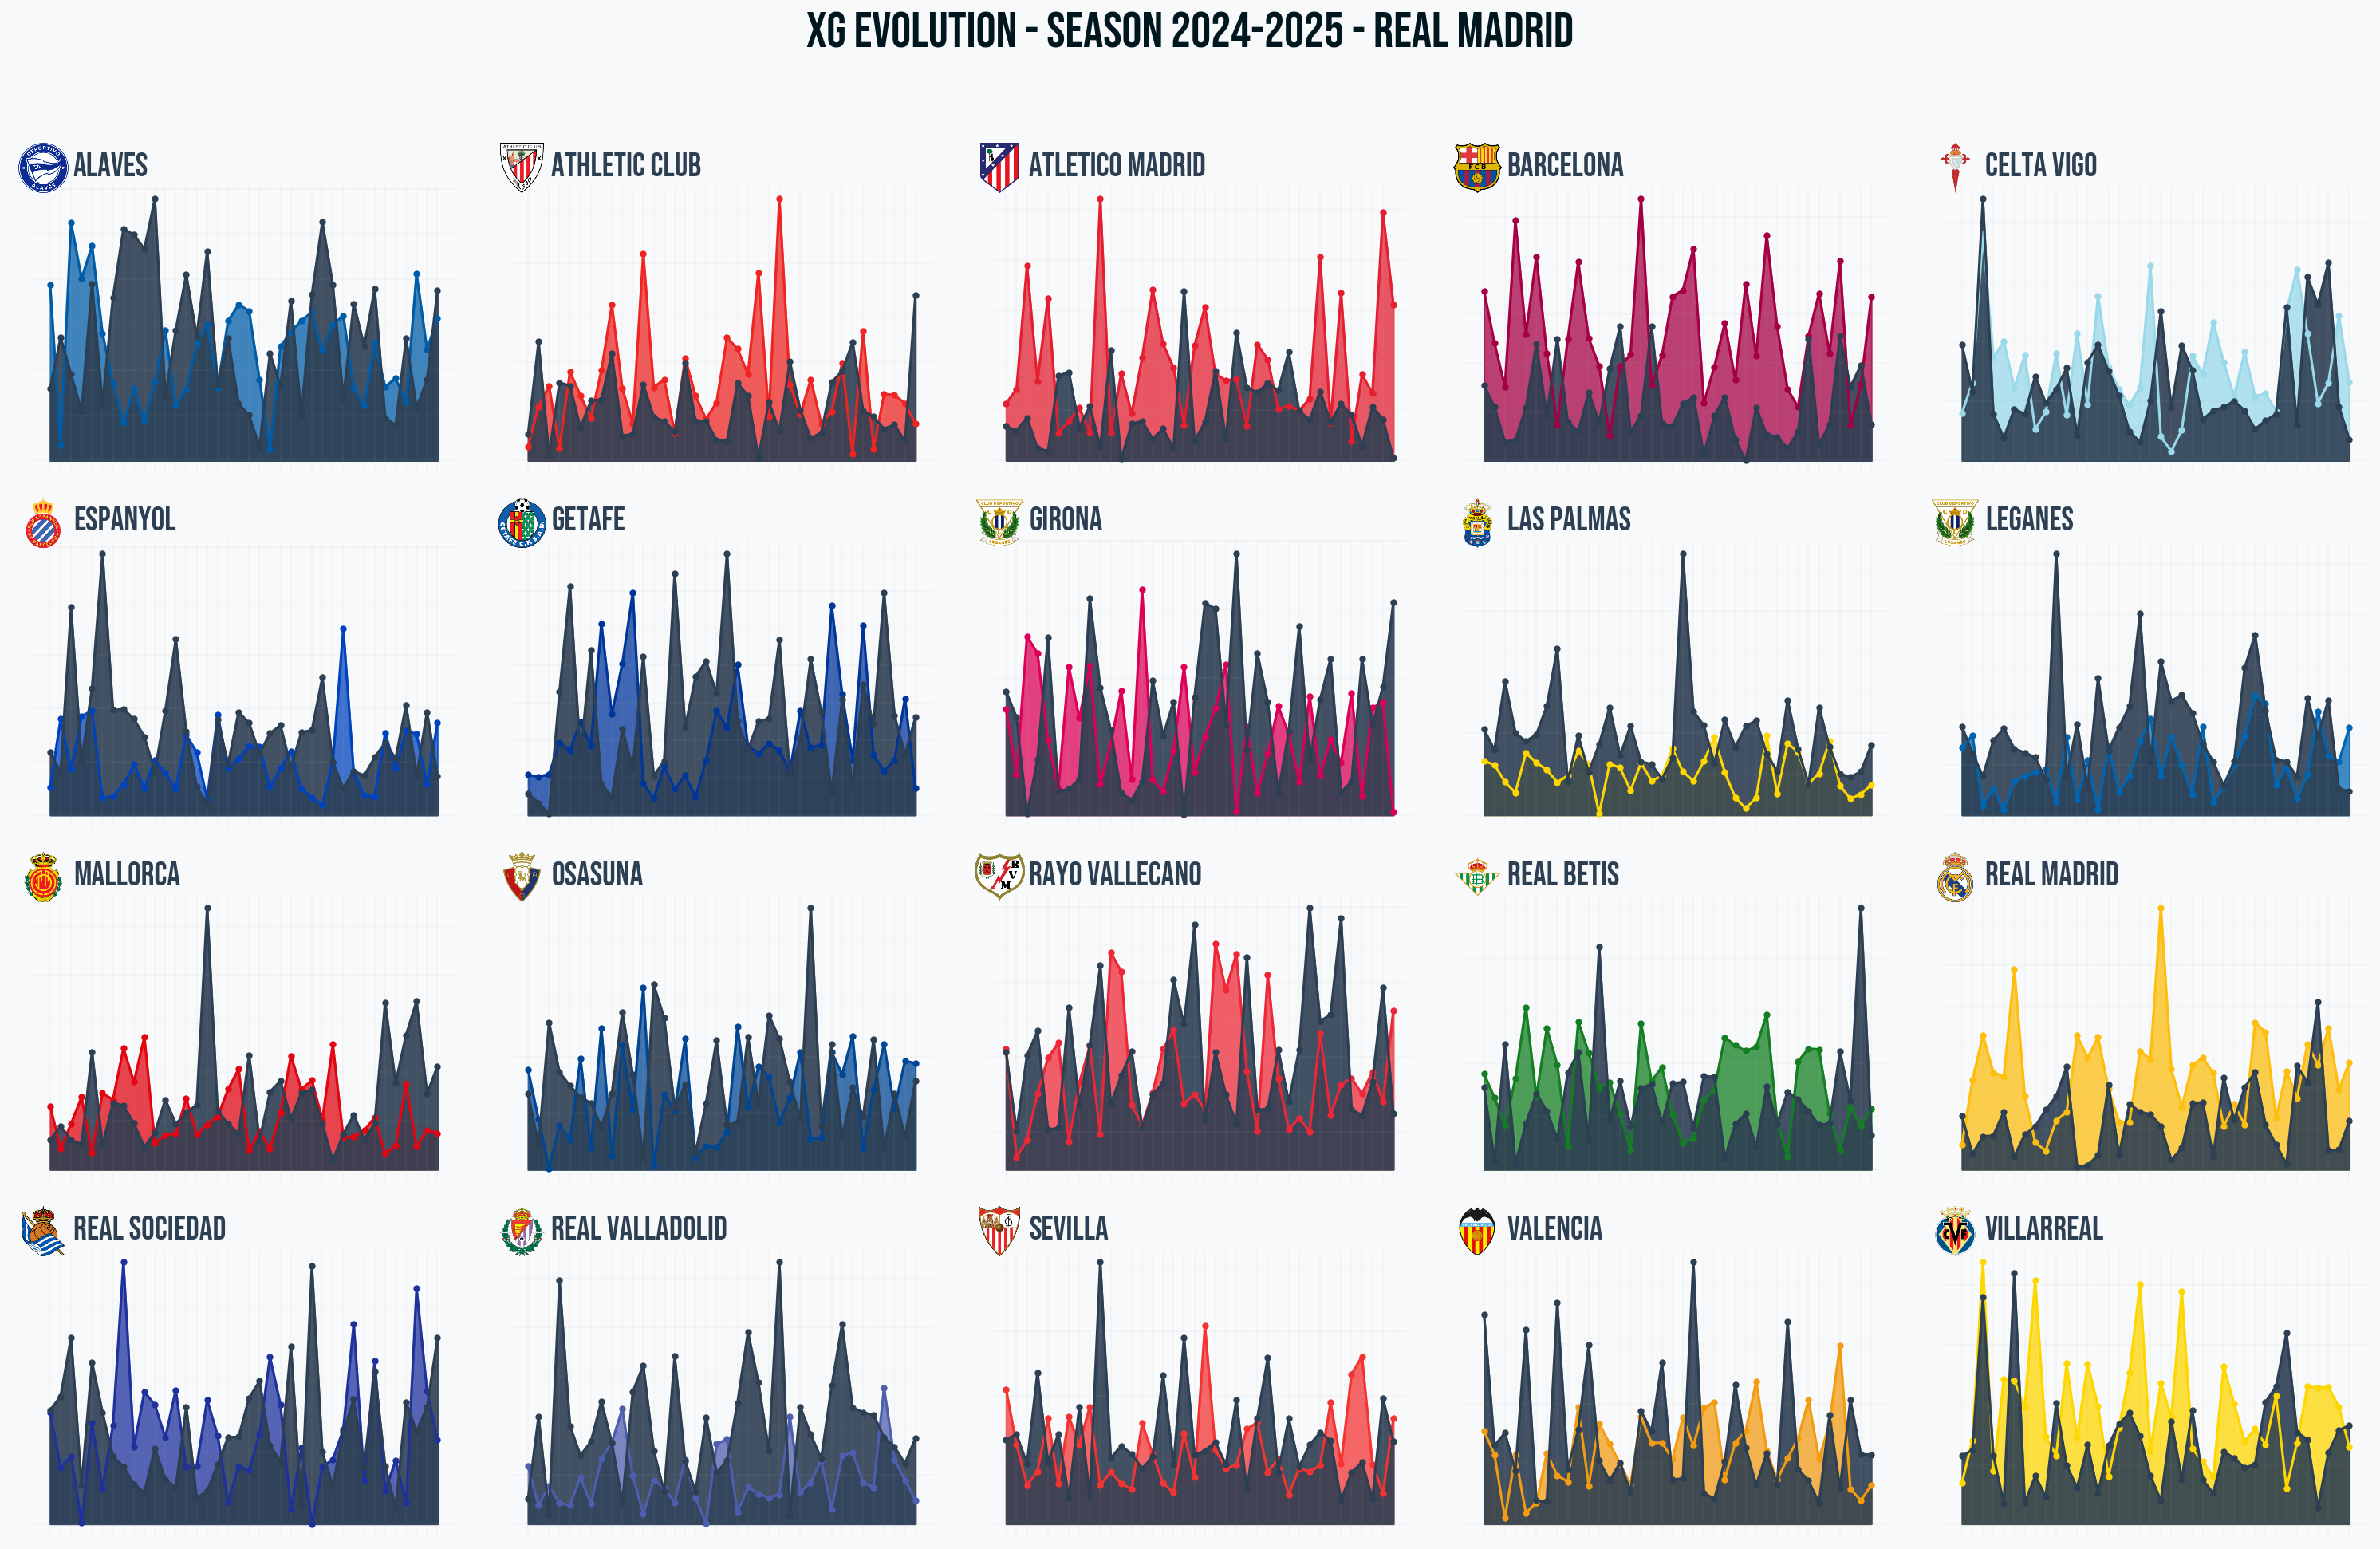

In [48]:
df_matches = get_team_matches(team, season)
teams = sorted(pd.concat([df_matches['h_title'], df_matches['a_title']]).unique())

df_team_mapping = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Providers_Team_Mapping.xlsx')

n = len(teams)
ncols = 5
nrows = math.ceil(n / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(20,3*nrows), dpi=150)

for teamx, ax in zip(teams, axs.flat):
    df_team = prepare_team_data(get_team_matches(teamx, season), teamx)
    plot_evolution_chart(df_team, teamx, df_team_mapping, ax)

# Eliminar los ejes sobrantes
for ax in axs.flat[len(teams):]:
    ax.remove()

title = f'xG Evolution - Season {season}-{season_end} - {team}'
fig.suptitle(title,fontproperties=font_title.prop,fontsize=30,color='#00171f',fontweight='bold',x=0.5, y=1.075,ha='center')